In [1]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

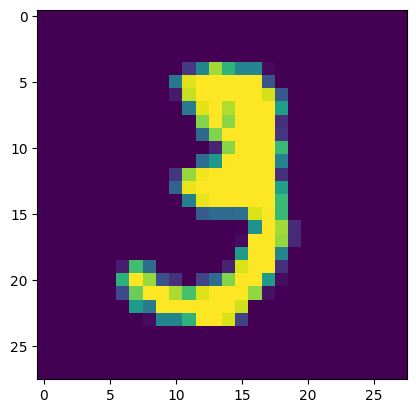

In [3]:
print(x_train[10])
plt.imshow(x_train[10])

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# Model
model = keras.Sequential([

    # 2D image → 1D
    keras.layers.Flatten(input_shape=(28,28)),

    # Hidden layer
    keras.layers.Dense(256, activation='relu'),

    # Output layer
    keras.layers.Dense(10, activation='softmax')

])

d:\Ostad\AI with Robotics\TensorFlow practice\env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Train
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9341 - loss: 0.2273
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9716 - loss: 0.0938
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9814 - loss: 0.0619
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9864 - loss: 0.0442
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0326
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9921 - loss: 0.0252
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9930 - loss: 0.0214
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9951 - loss: 0.0152
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9956 - loss: 0.0142
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.0117
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9970 - loss: 0.0097
Epoch 12/50
1875/1875 ━━━━━━━━

In [10]:
# Test
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9800 - loss: 0.1671
Accuracy: 0.9800000190734863


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction Probabilities:
[[1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 6.7931790e-25
  6.6061919e-32 1.6745001e-22 2.4244411e-38 0.0000000e+00 9.0648250e-18]]
Predicted Digit: 0
Real Digit: 0


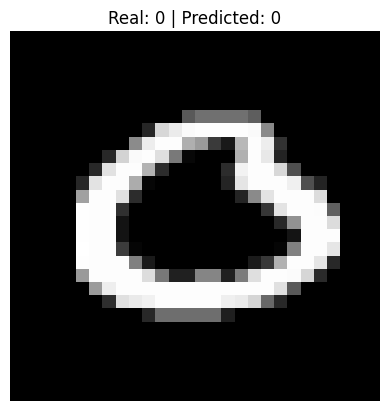

In [11]:
# Random image select
index = np.random.randint(0, len(x_test))

# Image
image = x_test[index]

# Real label
real_label = y_test[index]

# Prediction
prediction = model.predict(np.array([image]))

# Predicted digit
predicted_label = np.argmax(prediction)

# Show image
plt.imshow(image, cmap='gray')
plt.title(f"Real: {real_label} | Predicted: {predicted_label}")
plt.axis('off')

print("Prediction Probabilities:")
print(prediction)

print("Predicted Digit:", predicted_label)
print("Real Digit:", real_label)

plt.show()

In [12]:
# Save model
model.save("mnist_model.h5")